Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [1]:
from pathlib import Path
import sys, importlib
import os

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_fast"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)


Project root directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package
Experiment directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast
RAW data directory: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\raw


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


In [3]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper

DataImportWrapper().clean_all()

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Datasets:   0%|          | 0/8 [00:00<?, ?it/s]          

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[CAPTION] Histogram of v1 before and after cleaning.
[CAPTION] Histogram of v2 before and after cleaning.
[CAPTION] Histogram of v3 before and after cleaning.
[CAPTION] Histogram of v4 before and after cleaning.
[CAPTION] Histogram of v5 before and after cleaning.
[CAPTION] Histogram of v6 before and after cleaning.
[CAPTION] Histogram of v7 before and after cleaning.
[CAPTION] Histogram of v8 before and after cleaning.
[CAPTION] Histogram of v9 before and after cleaning.
[CAPTION] Histogram of v10 before and after cleaning.
[CAPTION] Histogram of v11 before and after cleaning.
[CAPTION] Histogram of v12 before and after cleaning.
[CAPTION] Histogram of v13 before and after cleaning.
[CAPTION] Histogram of v14 before and after cleaning.
[CAPTION] Histogram of v15 before and after cleaning.
[CAPTION] Histogram of v16 before and after cleaning.
[CAPTION] Histogram of v17 before and after cleaning.
[CAPTION] Histogram of v18 before and after c

Datasets:  12%|█▎        | 1/8 [00:14<01:44, 14.93s/it]

[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[CAPTION] Histogram of v1 before and after cleaning.
[CAPTION] Histogram of v2 before and after cleaning.
[CAPTION] Histogram of v3 before and after cleaning.
[CAPTION] Histogram of v4 before and after cleaning.
[CAPTION] Histogram of v5 before and after cleaning.
[CAPTION] Histogram of v6 before and after cleaning.
[CAPTION] Histogram of v7 before and after cleaning.
[CAPTION] Histogram of v8 before and after cleaning.
[CAPTION] Histogram of v9 before and after cleaning.
[CAPTION] Histogram of v10 before and after cleaning.
[CAPTION] Histogram of v11 before and after cleaning.
[CAPTION] Histogram of v12 before and after cleaning.
[CAPTION] Histogram of v13 before and after cleaning.
[CAPTION] Histogram of v14 before and after cleaning.
[CAPTION] Histogram of v15 before and after cleaning.
[CAPTION] Histogram of v16 before and after cleaning.
[CAPTION] Histogram of v17 before and after cleaning.
[CAPTION] Histogram of v18 before and after

Datasets:  25%|██▌       | 2/8 [00:28<01:26, 14.37s/it]

[REPORT] cleaned cheetah: shape=(781, 141)
[CAPTION] Histogram of v1 before and after cleaning.
[CAPTION] Histogram of v2 before and after cleaning.
[CAPTION] Histogram of v3 before and after cleaning.
[CAPTION] Histogram of v4 before and after cleaning.
[CAPTION] Histogram of v5 before and after cleaning.
[CAPTION] Histogram of v6 before and after cleaning.
[CAPTION] Histogram of v7 before and after cleaning.
[CAPTION] Histogram of v8 before and after cleaning.
[CAPTION] Histogram of v9 before and after cleaning.
[CAPTION] Histogram of v10 before and after cleaning.
[CAPTION] Histogram of v11 before and after cleaning.
[CAPTION] Histogram of v12 before and after cleaning.
[CAPTION] Histogram of v13 before and after cleaning.
[CAPTION] Histogram of v14 before and after cleaning.
[CAPTION] Histogram of v15 before and after cleaning.
[CAPTION] Histogram of v16 before and after cleaning.
[CAPTION] Histogram of v17 before and after cleaning.
[CAPTION] Histogram of v18 before and after clea

Datasets:  38%|███▊      | 3/8 [00:42<01:10, 14.14s/it]

[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[CAPTION] Histogram of dist1_2 before and after cleaning.
[CAPTION] Histogram of dist1_3 before and after cleaning.
[CAPTION] Histogram of dist1_4 before and after cleaning.
[CAPTION] Histogram of dist1_5 before and after cleaning.
[CAPTION] Histogram of dist1_6 before and after cleaning.
[CAPTION] Histogram of dist1_7 before and after cleaning.
[CAPTION] Histogram of dist1_8 before and after cleaning.
[CAPTION] Histogram of dist1_9 before and after cleaning.
[CAPTION] Histogram of dist1_10 before and after cleaning.
[CAPTION] Histogram of dist1_11 before and after cleaning.
[CAPTION] Histogram of dist1_12 before and after cleaning.
[CAPTION] Histogram of dist1_13 before and after cleaning.
[CAPTION] Histogram of dist1_14 before and after cleaning.
[CAPTION] Histogram of dist1_15 before and after cleaning.
[CAPTION] Histogram of dist1_16 before and after cleaning.
[CAPTION] Histogram of dist1_17 before and after cleaning.
[CAPTION] Hist

: 

Overview generation of Datasets in experiment

In [ ]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.csv', reuse_csv=True)
overview_df

Datasets: 100%|██████████| 8/8 [00:00<00:00, 470.56it/s] 


,Species,No. of footprints,No. of known individuals,No. of trails,No. of measurements
0,Amur Tiger (Panthera tigris altaica),605,44,86,128
1,Bengal Tiger (Panthera tigris tigris),586,40,87,128
2,Cheetah (Acinonyx jubatus),781,38,110,135
3,Eurasian Otter (Lutra lutra),628,42,80,205
4,Giant Panda (Ailuropoda melanoleuca),523,42,77,122
5,Lowland Tapir (Tapirus terrestris),426,37,64,90
6,Mountain Lion (Puma concolor),535,35,78,131
7,White Rhinoceros (Ceratotherium simum),1273,41,154,104


Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


Splitting datasets:  12%|█▎        | 1/8 [00:00<00:00,  8.13it/s]

✔️ Fold-Spalte in amur_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     89
1     98
2     92
3    104
4     90

📊 amur_tiger – train – 473 Zeilen | 35 Individuen | 66 Trails
sex
f    264
m    209

📊 amur_tiger – test – 132 Zeilen | 9 Individuen | 21 Trails
sex
f    80
m    52

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (csv & parquet)
✔️ Fold-Spalte in bengal_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0     94
1     84
2    114
3     91
4     94


Splitting datasets:  25%|██▌       | 2/8 [00:00<00:00,  7.34it/s]


📊 bengal_tiger – train – 477 Zeilen | 27 Individuen | 69 Trails
sex
m    291
f    186

📊 bengal_tiger – test – 71 Zeilen | 7 Individuen | 11 Trails
sex
m    37
f    34

📊 bengal_tiger – inference – 38 Zeilen | 6 Individuen | 7 Trails
sex
unknown    38

✅ bengal_tiger gespeichert (csv & parquet)
✔️ Fold-Spalte in cheetah schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    122
1    112
2    128
3    120
4    135

📊 cheetah – train – 617 Zeilen | 30 Individuen | 87 Trails
sex
f    316
m    301

📊 cheetah – test – 164 Zeilen | 8 Individuen | 23 Trails
sex
m    94
f    70

📊 cheetah – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ cheetah gespeichert (csv & parquet)


Splitting datasets:  38%|███▊      | 3/8 [00:00<00:00,  6.86it/s]C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids


...


[DEBUG] df is empty, returning empty summary

[DEBUG] compute_summary called for mountain_lion/test, df shape = (105, 138)
[DEBUG] ds_label = mountain_lion Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['puma_concolor']
[DEBUG] species_code = puma concolor
[DEBUG] sex value counts:
sex
Female    61
Male      44
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (61, 138)
[DEBUG]  n_fp=61, n_ind=4, n_tr=9
[DEBUG]   fp_per_ind summary: mean=15.25, sd=5.539629951540085
[DEBUG]   tr_per_ind summary: mean=2.25, sd=0.82915619758885
[DEBUG] sex = Male, subset shape = (44, 138)
[DEBUG]  n_fp=44, n_ind=3, n_tr=6
[DEBUG]   fp_per_ind summary: mean=14.666666666666666, sd=1.8856180831641267
[DEBUG]   tr_per_ind summary: mean=2.0, sd=0.0
[DEBUG] sex = Unknown, subset shape = (0, 138)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] Returning summary DataFram


[DEBUG] compute_summary called for white_rhino/inference, df shape = (0, 117)
[DEBUG] df is empty, returning empty summary


Datasets: 100%|██████████| 8/8 [00:00<00:00, 15.02it/s]


[DEBUG] compute_summary called for white_rhino/test, df shape = (332, 117)
[DEBUG] ds_label = white_rhino Test
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['ceratotherium_simum']
[DEBUG] species_code = ceratotherium simum
[DEBUG] sex value counts:
sex
Female    203
Male      129
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (203, 117)
[DEBUG]  n_fp=203, n_ind=5, n_tr=25
[DEBUG]   fp_per_ind summary: mean=40.6, sd=14.093970341958293
[DEBUG]   tr_per_ind summary: mean=5.6, sd=1.8547236990991407
[DEBUG] sex = Male, subset shape = (129, 117)
[DEBUG]  n_fp=129, n_ind=4, n_tr=16
[DEBUG]   fp_per_ind summary: mean=32.25, sd=12.397076268217438
[DEBUG]   tr_per_ind summary: mean=4.5, sd=1.5
[DEBUG] sex = Unknown, subset shape = (0, 117)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summ

[CAPTION] Summary counts for all species
[CAPTION] Summary counts for all species
[CAPTION] Counts for acinonyx jubatus
[CAPTION] Counts for acinonyx jubatus
[CAPTION] Counts for ailuropoda melanoleuca
[CAPTION] Counts for ailuropoda melanoleuca
[CAPTION] Counts for ceratotherium simum
[CAPTION] Counts for ceratotherium simum
[CAPTION] Counts for lutra lutra
[CAPTION] Counts for lutra lutra
[CAPTION] Counts for panthera tigris altaica
[CAPTION] Counts for panthera tigris altaica
[CAPTION] Counts for panthera tigris tigris
[CAPTION] Counts for panthera tigris tigris
[CAPTION] Counts for puma concolor
[CAPTION] Counts for puma concolor
[CAPTION] Counts for tapirus terrestris
[CAPTION] Counts for tapirus terrestris
[CAPTION] Fraction of footprints per split
[CAPTION] Fraction of footprints per split


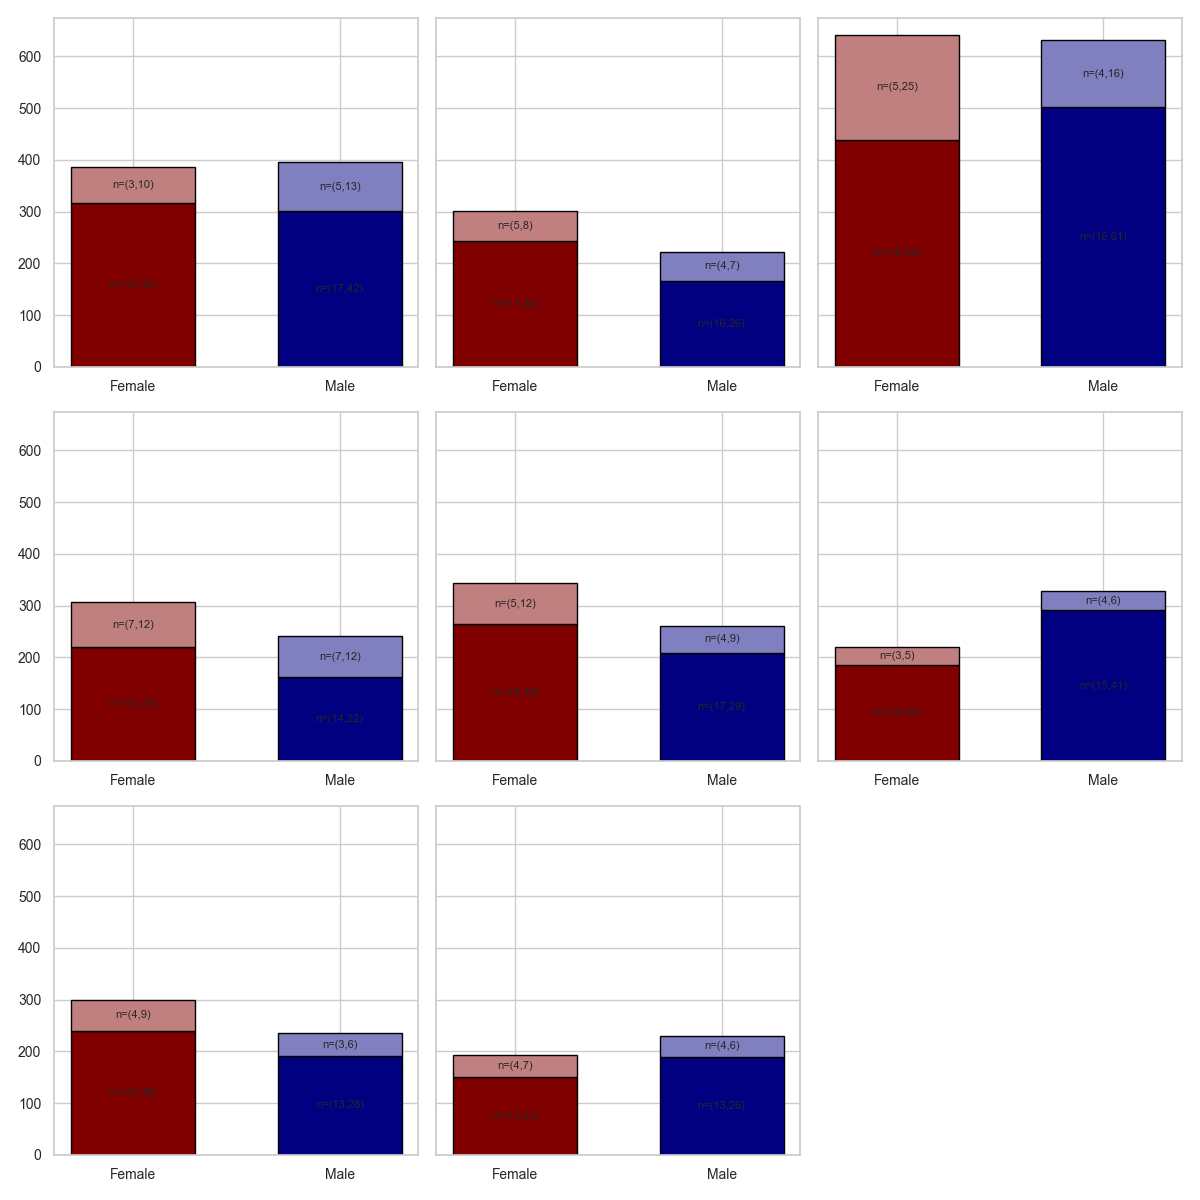

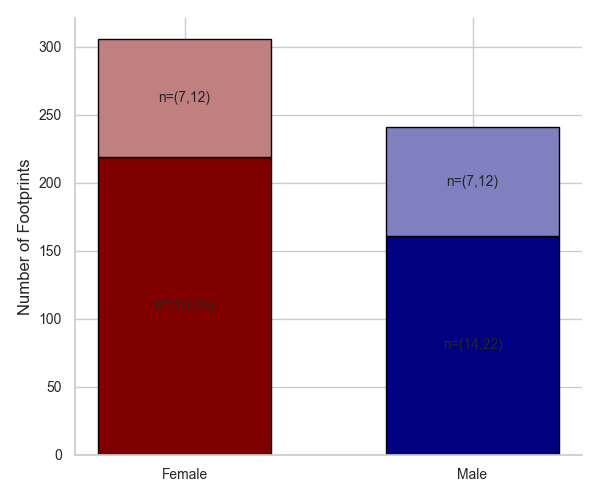

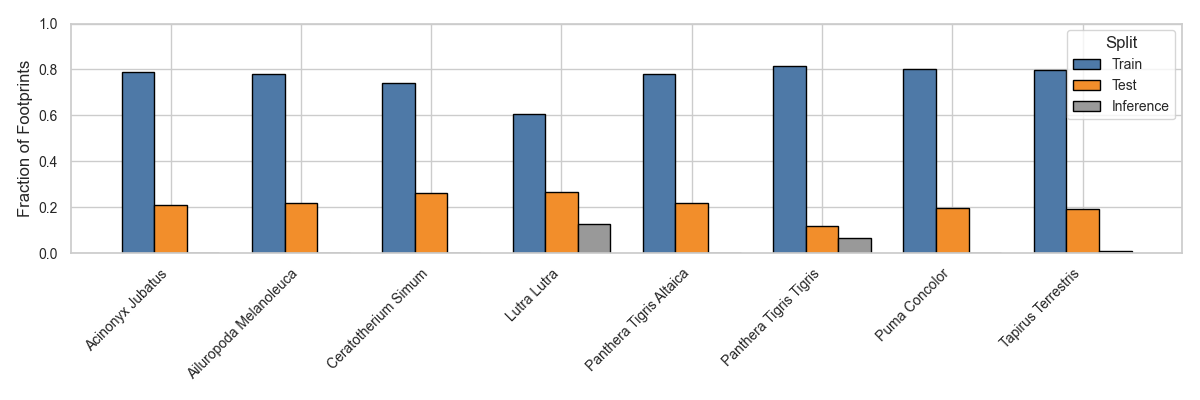

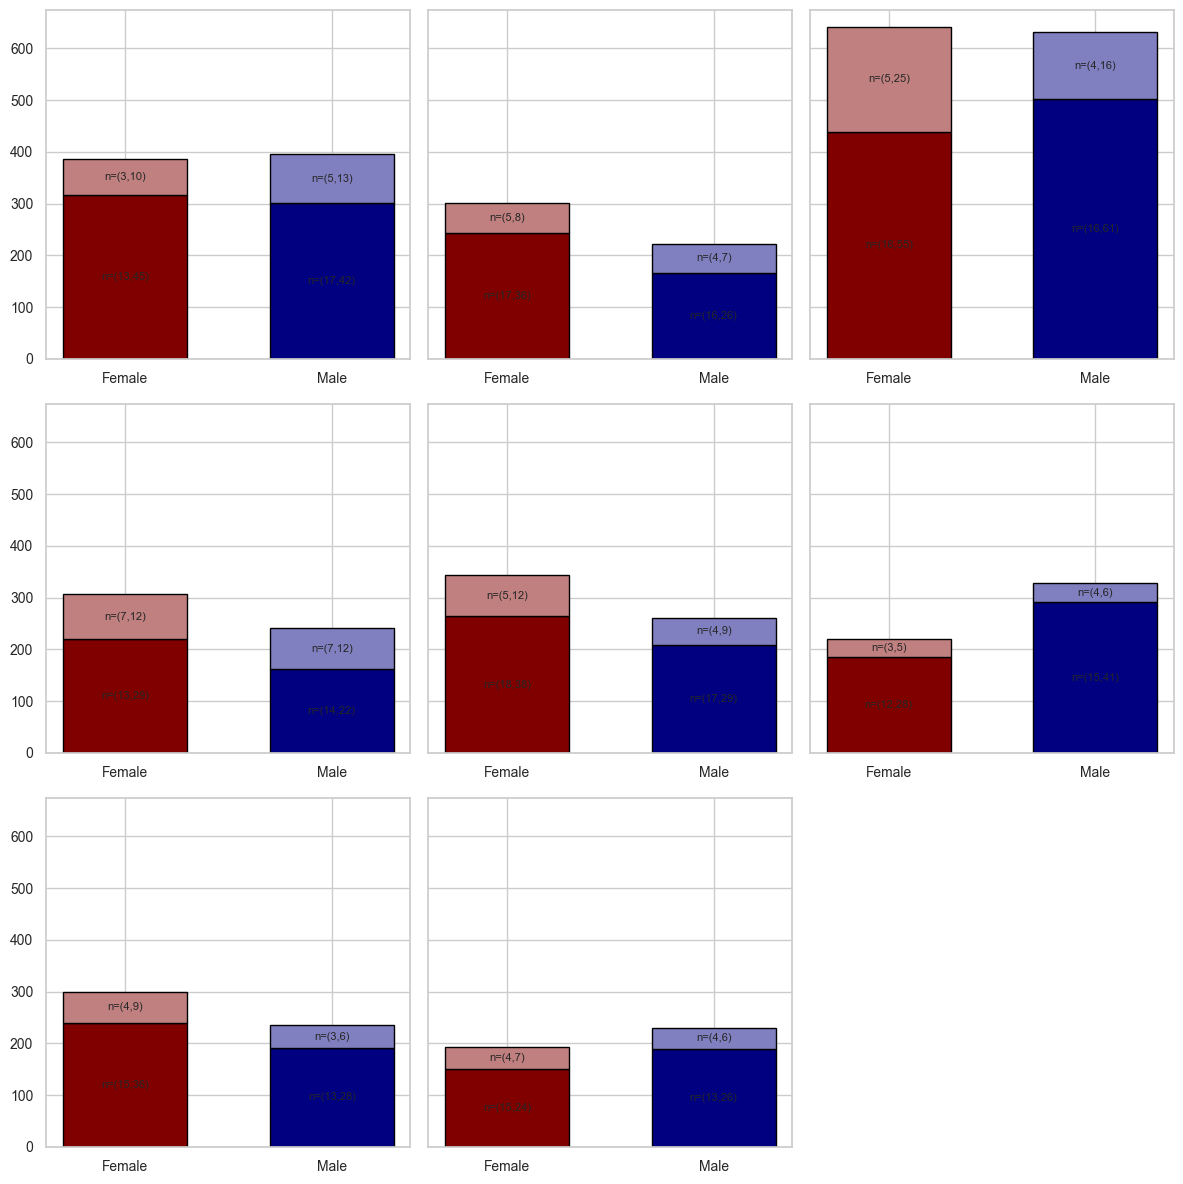

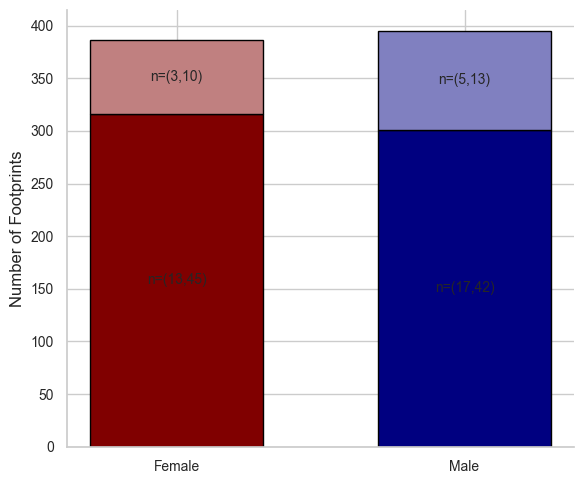

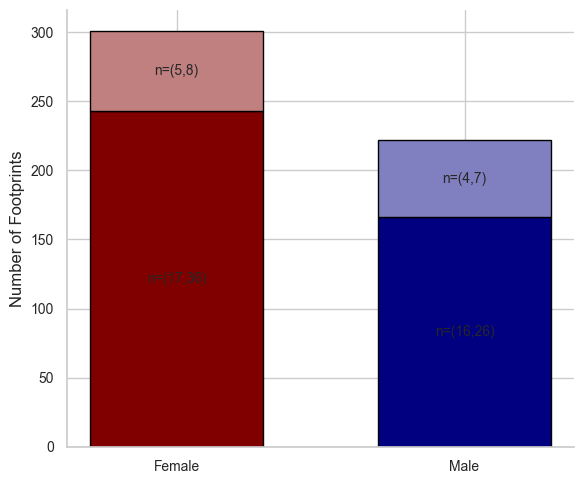

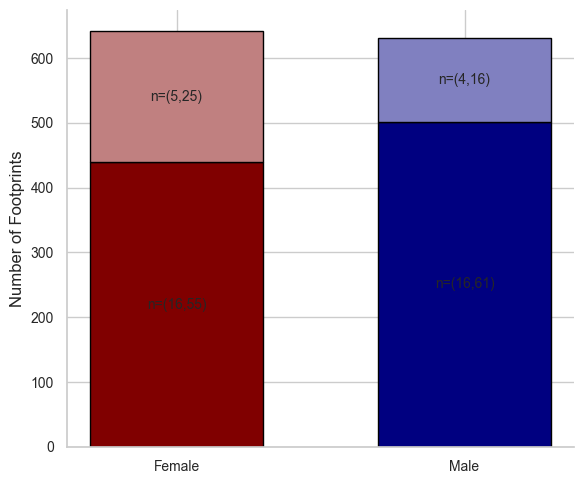

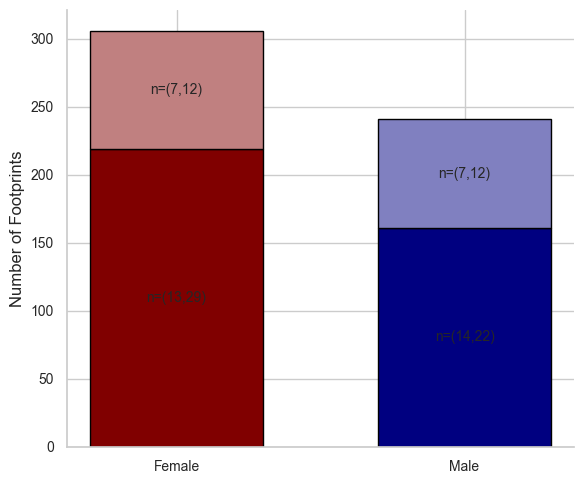

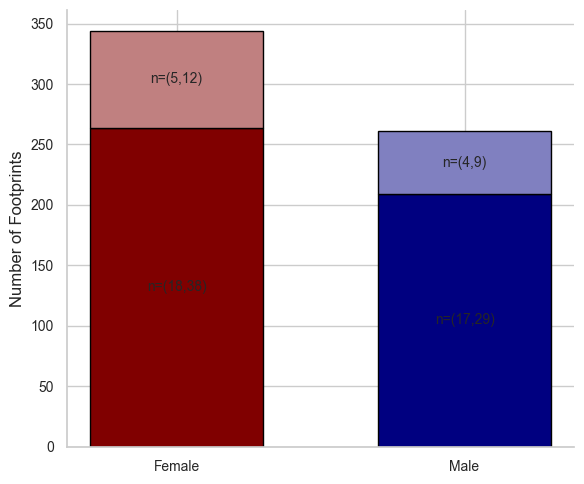

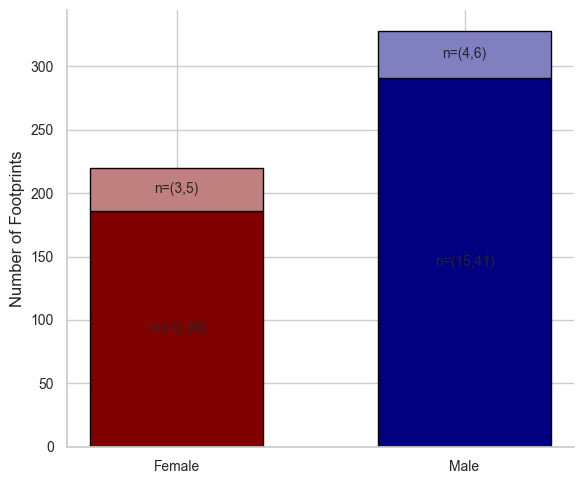

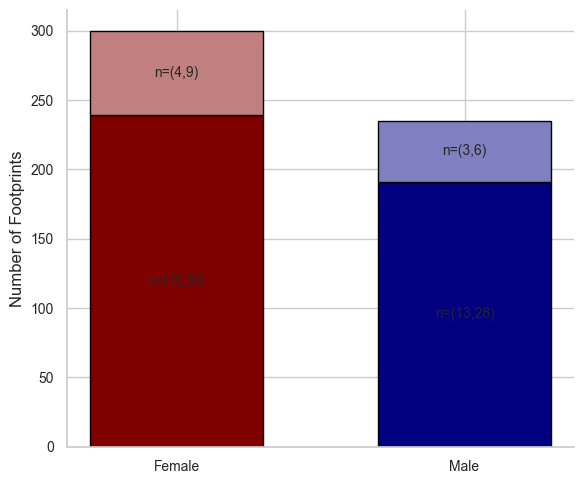

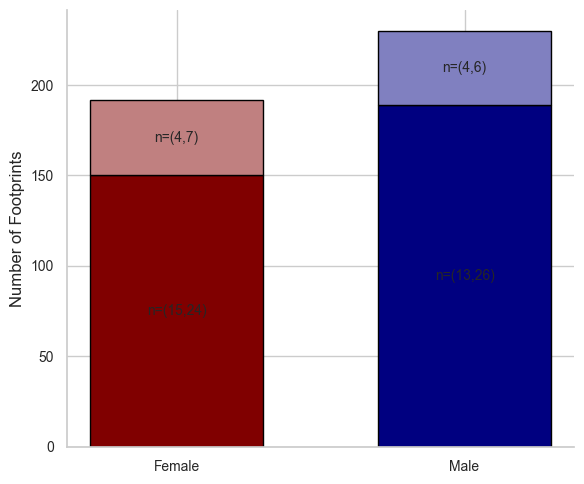

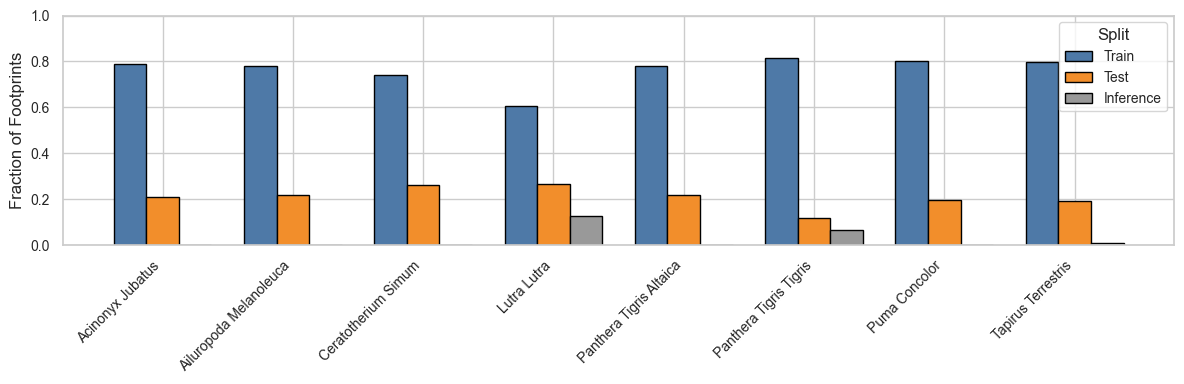

In [ ]:

from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from IPython.display import Image, display
import pandas as pd
SplitWrapper().split_all(reuse_splits=True)
run_summary(cfg.SPLITS_DIR, EXP_DIR/'split_summary.csv', EXP_DIR/'split_fig')
display(Image(filename=EXP_DIR/'split_fig/summary_all.png'))
display(Image(filename=EXP_DIR/'split_fig/lutra_lutra_summary.png'))
display(Image(filename=EXP_DIR/'split_fig/split_proportions.png'))



Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [ ]:
from FIT_python.Visualisations.plot_style import map_sex
from FIT_python import config as cfg

from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    select_top_features,
    plot_sex_boxplots,
    plot_individual_boxplots,
)
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# Pfad zur Datei
#file_path = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\data\cleaned\Eurasian_Otter.parquet")
file_path = cfg.CLEANED_DIR / "Eurasian_Otter.parquet"


# Unterordner für Data Exploration anlegen
exp_dir_dataexpl = EXP_DIR / "data_exploration_figures"
exp_dir_dataexpl.mkdir(parents=True, exist_ok=True)

# Laden des DataFrames
otter_df = pd.read_parquet(file_path)

otter_df = otter_df.dropna(subset=['sex', 'individual_id'])
otter_df = otter_df[~otter_df['sex'].astype(str).str.lower().eq('na')]
otter_df = otter_df[~otter_df['individual_id'].astype(str).str.lower().eq('na')]
otter_df['sex_mapped'] = map_sex(otter_df['sex'])

top_sex = select_top_features(otter_df, 'sex', k=4)
top_ind = select_top_features(otter_df, 'individual_id', k=4)


plot_feature_correlation_matrix(otter_df, exp_dir_dataexpl)
plot_sex_boxplots(otter_df, top_sex, exp_dir_dataexpl, 'sex_boxplots.png')
plot_individual_boxplots(otter_df, top_ind, exp_dir_dataexpl, 'individual_boxplots.png')



[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist10_13'] by sex (Female, Male).
[CAPTION] Boxplots of ['dist12_14', 'dist13_15', 't2_3_5', 't12_13_15'] grouped by individual


WindowsPath('c:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/notebooks/results/fit_notebook_fast/data_exploration_figures/individual_boxplots.png')

Visualisierung mit Umap alle Otter

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Frede\AppData\Local\Temp\ipykernel_22764\4165001939.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_22764\4165001939.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
C:\Users\Frede\AppData\Local\Temp\ipykernel_22764\4165001939.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('_').  Matplotlib is ignoring the ed

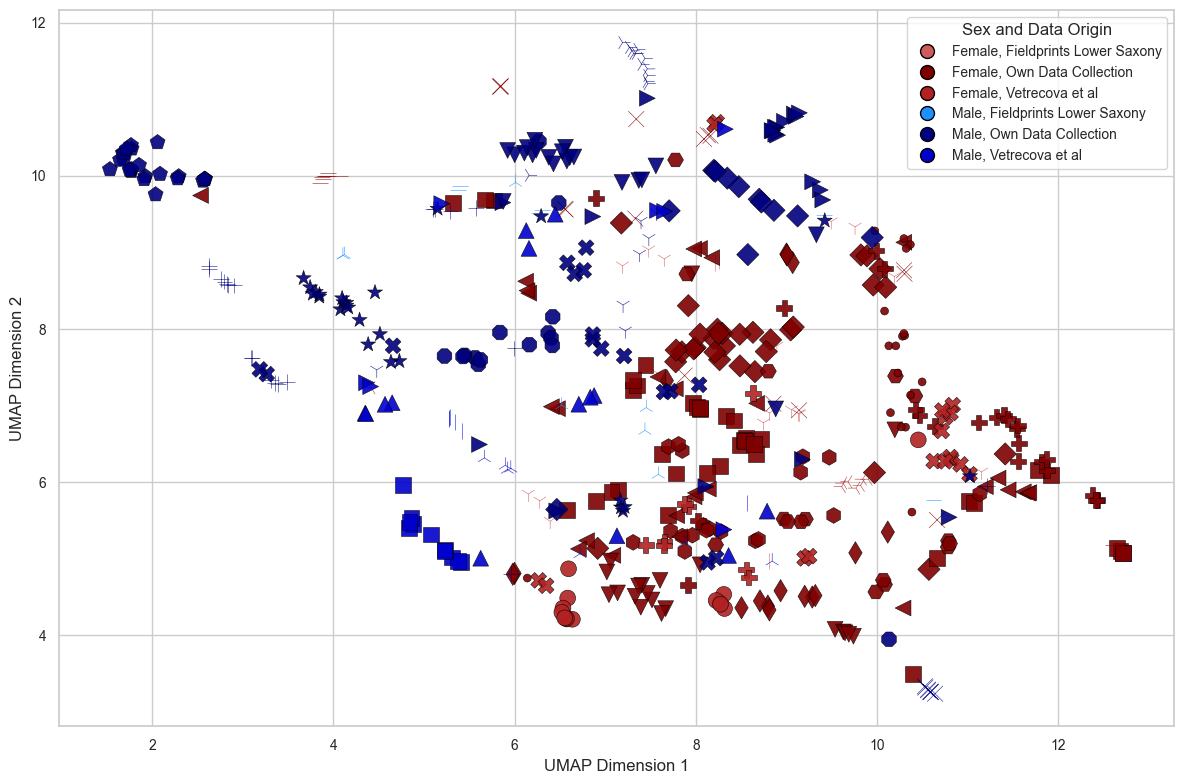

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed
dr = DimensionalityReducerTransformer(
    method='umap',
    supervised=True,
    random_state=42    # Seed für Reproduzierbarkeit
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)
# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Kräftigere Farbpaletten für Sex mit klareren Schattierungen
sex_palette = {
    'Female': ["#800000", "#B22222", "#CD5C5C"],   # Dunkelrot → Rot → Hellrot
    'Male': ["#000080", "#0000CD", "#1E90FF"]      # Navy → Mittelblau → Hellblau
}
origin_order = ['Own Data Collection', 'Vetrecova et al', 'Fieldprints Lower Saxony']

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    palette = sex_palette[row['sex_mapped']]
    idx = origin_order.index(row['dataorigin']) % len(palette)
    return palette[idx]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen
fig, ax = plt.subplots(figsize=(12, 8))
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,          # Noch größere Marker
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")

# Legende nur mit Kreisen
from matplotlib.lines import Line2D
legend_elements = []
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    legend_elements.append(Line2D(
        [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
        markerfacecolor=group['color'].iloc[0], markersize=10, markeredgecolor='black'
    ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=10)

plt.tight_layout()

# Speichern
fig_path = Path(exp_dir_dataexpl) / "umap_individuals_sex_origin_bigmarkers_simplelegend.png"
plt.savefig(fig_path, dpi=300)
plt.show()


Training sex Model

In [ ]:
# ────────────────────────────────────────────────────────────────
# Sex Classification: Model Training with Bayesian Optimisation
# ────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier  # Optional, falls CatBoost aktiv
from FIT_python.pipeline_sex.sex_config import run_otter_search_sex, run_other_species_search
from FIT_python.pipeline_sex import collect_best_metrics
import FIT_python.config as cfg

# deine vorhandenen Helper
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric

# ─── Models Definition ───────────────────────────────────────────
# ─── Models Definition (LDA, Logistic Regression, XGBoost Variants) ──────────
MODELS = {
    # Logistic Regression Variants
    "logreg_l2": LogisticRegression(
        penalty="l2", solver="lbfgs", C=1.0, max_iter=500
    ),
    "logreg_l1": LogisticRegression(
        penalty="l1", solver="saga", C=1.0, max_iter=500
    ),

    # LDA Baseline
    "lda": LinearDiscriminantAnalysis(),

    # XGBoost Variants
    "xgb_std": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_deep": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=10,
        subsample=0.9, colsample_bytree=0.9,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_fast": XGBClassifier(
        n_estimators=50, learning_rate=0.2, max_depth=4,
        subsample=0.8, colsample_bytree=0.7,
        use_label_encoder=False, verbosity=0
    ),
    "xgb_reg": XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.85, colsample_bytree=0.85,
        use_label_encoder=False, verbosity=0
    ),
}
# BayesSearchCV ausführen (legt automatisch species-bezogene Unterordner an)
run_otter_search_sex()       # Otter
run_other_species_search()   # alle übrigen Spezies

# Zusammenfassung der besten Modelle für Auswertung und Visualisierung
summary_df = collect_best_metrics(cfg.RESULTS_DATA_DIR)

eurasian_otter BS-CV:   0%|          | 0/15 [00:00<?, ?it/s]

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits


35it [00:23,  1.48it/s]
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.320e-03, tolerance: 6.296e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.452e-03, tolerance: 6.296e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.

...

✅ Modell für Spezies 'white_rhino', Kriterium 'balanced_test_acc' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\white_rhino_bayes_search_standard_metrics\best_balanced_test_acc\white_rhino.joblib


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.401e-02, tolerance: 1.567e-02
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.907e-02, tolerance: 1.567e-02
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

✅ Modell für Spezies 'white_rhino', Kriterium 'accuracy_test' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\white_rhino_bayes_search_standard_metrics\best_accuracy_test\white_rhino.joblib


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.127e-02, tolerance: 1.567e-02
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.503e-02, tolerance: 1.567e-02
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

✅ Modell für Spezies 'white_rhino', Kriterium 'mean_test_neg_log_loss' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\white_rhino_bayes_search_standard_metrics\best_mean_test_neg_log_loss\white_rhino.joblib
✅ Best-Overall-Rank Modell für Spezies 'white_rhino' gespeichert unter:
   c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\white_rhino_bayes_search_standard_metrics\best_mean_rank\white_rhino.joblib
[CAPTION] Mean CV accuracy by selector and reducer
[CAPTION] Mean CV accuracy by selector and reducer


Best Models Ballaned accuracy , majority individual  classification , accuracy , und mean log loss For otter

inference for inference sets for 4 models balanced acc ; maj test; beg loss ; accuracy

Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast
Base data dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data
Benchmark dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\benchmark
✅ Benchmark-Tabelle gespeichert unter: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\benchmark\benchmark_summary.csv


,Species,Balanced Accuracy (Test),Accuracy (Test),Majority Vote Individual Accuracy (Test),Female Accuracy (Test),Male Accuracy (Test),Accuracy (CV),Balanced Accuracy (CV),Log Loss (CV),Mean Rank
1,Amur Tiger,0.962,0.970,1.000,1.000,0.921,0.886,0.888,-0.450,1.250
2,Bengal Tiger,0.945,0.944,0.857,0.933,0.850,0.723,0.705,-1.659,1.583
0,Mountain Lion,0.821,0.848,0.857,0.958,0.681,0.874,0.860,-0.512,1.417
2,Eurasian Otter,0.807,0.808,1.000,0.812,0.806,0.798,0.758,-0.837,1.333
0,Giant Panda,0.788,0.789,0.778,0.858,0.564,0.669,0.731,-0.987,1.250
0,Lowlandtapir,0.542,0.542,0.625,0.665,0.445,0.487,0.489,-1.364,1.500
2,Cheetah,0.481,0.463,0.500,0.641,0.430,0.479,0.529,-0.833,1.750
1,White Rhino,0.455,0.470,0.556,0.492,0.488,0.517,0.524,-1.609,1.417


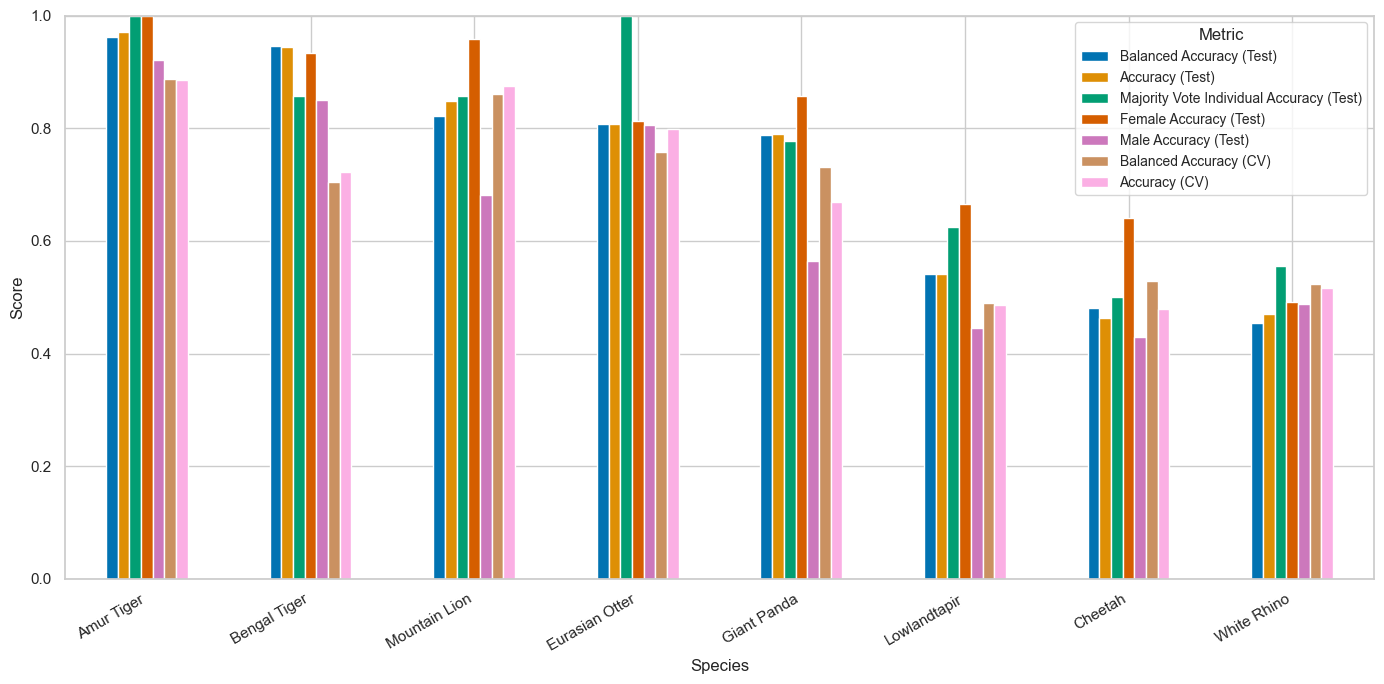

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, sys, importlib

# ---------------------------------------------------------------------
# Projekt-Setup über config
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# Basis- und Ergebnis-Verzeichnisse aus config
base_dir = config.RESULTS_DATA_DIR
benchmark_dir = config.EXPERIMENT_ROOT / "benchmark"
benchmark_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", config.EXPERIMENT_ROOT)
print("Base data dir:", base_dir)
print("Benchmark dir:", benchmark_dir)

benchmark_rows = []

# Sammeln der besten Modelle pro Spezies
for species_dir in base_dir.glob("*"):
    best_csv = species_dir / "best_models.csv"
    all_csv = species_dir / "all_results.csv"

    if best_csv.exists() and all_csv.exists():
        df_best = pd.read_csv(best_csv)
        df_all = pd.read_csv(all_csv)

        # --- Ranking für all_results.csv ---
        metrics = [
            "mean_test_accuracy",
            "mean_test_balanced_accuracy",
            "mean_test_neg_log_loss",
            "maj_test_pct",
            "balanced_test_acc",
            "accuracy_test"
        ]
        for metric in metrics:
            if "neg_log_loss" in metric:  # kleiner ist besser
                df_all[metric + "_rank"] = df_all[metric].rank(ascending=True)
            else:  # größer ist besser
                df_all[metric + "_rank"] = df_all[metric].rank(ascending=False)

        rank_cols = [m + "_rank" for m in metrics]
        df_all["mean_rank"] = df_all[rank_cols].mean(axis=1)

        # Modell mit bestem Mean Rank auswählen
        best_row = df_all.sort_values("mean_rank").iloc[0]
        benchmark_rows.append(best_row)

benchmark_df = pd.DataFrame(benchmark_rows)

# Spalten sauber benennen (Test und CV getrennt)
col_map = {
    "species": "Species",
    # Test-Metriken
    "balanced_test_acc": "Balanced Accuracy (Test)",
    "accuracy_test": "Accuracy (Test)",
    "maj_test_pct": "Majority Vote Individual Accuracy (Test)",
    "female_test_acc": "Female Accuracy (Test)",
    "male_test_acc": "Male Accuracy (Test)",
    # CV-Metriken
    "mean_test_accuracy": "Accuracy (CV)",
    "mean_test_balanced_accuracy": "Balanced Accuracy (CV)",
    "mean_test_neg_log_loss": "Log Loss (CV)",
    # Ranking
    "mean_rank": "Mean Rank"
}

cols_to_keep = [c for c in col_map.keys() if c in benchmark_df.columns]
benchmark_df = benchmark_df[cols_to_keep]
benchmark_df = benchmark_df.rename(columns=col_map)

# Species-Namen säubern
benchmark_df["Species"] = (
    benchmark_df["Species"]
    .str.replace("_", " ")
    .str.title()
)

# Runden und sortieren nach Balanced Accuracy (Test)
benchmark_df = benchmark_df.round(3)
benchmark_df = benchmark_df.sort_values(by="Balanced Accuracy (Test)", ascending=False)

# Speichern
out_path = benchmark_dir / "benchmark_summary.csv"
benchmark_df.to_csv(out_path, index=False)
print(f"✅ Benchmark-Tabelle gespeichert unter: {out_path}")
display(benchmark_df)

# Plot mit sns Farbpalette
sns.set_style("whitegrid")
palette = sns.color_palette("colorblind", n_colors=len(benchmark_df.columns) - 2)

# Plotten aller CV- und Testmetriken (ohne Mean Rank)
metrics_for_plot = [
    "Balanced Accuracy (Test)",
    "Accuracy (Test)",
    "Majority Vote Individual Accuracy (Test)",
    "Female Accuracy (Test)",
    "Male Accuracy (Test)",
    "Balanced Accuracy (CV)",
    "Accuracy (CV)",
]

ax = benchmark_df.set_index("Species")[metrics_for_plot].plot(
    kind="bar", figsize=(14, 7), color=palette
)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Species", fontsize=12)
ax.legend(title="Metric", fontsize=10)
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_plot.png", dpi=300)
plt.show()


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.373e-02, tolerance: 4.343e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.616e-02, tolerance: 4.343e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

Verteilung nach Splits:
__split__
train        380
test         167
inference     81
Name: count, dtype: int64 



,id,species,individual_id,date,location,dataorigin,substrate,sex,trail,dist1_2,...,t12_13_15,t13_14_15,t13_14_17,t12_15_17,t13_14_16,Fold,__split__,pred_sex,pred_proba_f,pred_proba_m
0,1989,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.195434,...,45.614587,45.614587,22.519170,21.979226,16.757686,3.0,train,m,0.08,0.92
1,1990,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.078705,...,43.571373,43.571373,18.882423,19.962604,12.480125,3.0,train,m,0.38,0.62
2,1991,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.130907,...,40.660357,40.660357,19.281442,18.500245,13.776469,3.0,train,f,0.60,0.40
3,1992,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,2.211265,...,39.990505,39.990505,15.972883,15.033439,10.469460,3.0,train,m,0.16,0.84
4,1993,lutra_lutra,styx,None,Otter Station Pavlov,Vetrecova et al,Mud,m,styx,1.938635,...,46.219886,46.219886,22.458678,21.324311,16.092507,3.0,train,m,0.08,0.92


C:\Users\Frede\AppData\Local\Temp\ipykernel_22764\3884079147.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


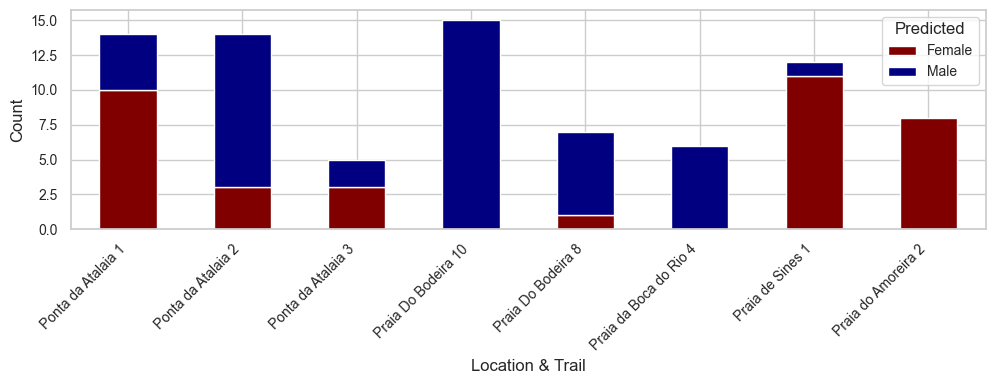

✅ Ergebnisse und Plots gespeichert in: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\results_data\eurasian_otter_bayes_search_standard_metrics


In [ ]:
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    predict_all, 
    plot_inference
)
import pandas as pd
import numpy as np
from pathlib import Path
import os, importlib

# ---------------------------------------------------------------------
# Config laden
# ---------------------------------------------------------------------
from FIT_python import config
importlib.reload(config)

# === Konfiguration ===
DEFAULT_SPECIES = "eurasian_otter"
METRIC_KEY = "best_mean_rank"

# --- Verzeichnis mit den besten Modellen (aus config) ---
BEST_MODEL_DIR = config.RESULTS_DATA_DIR / f"{DEFAULT_SPECIES}_bayes_search_standard_metrics"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# CSV neu erzeugen inkl. Inference mit OOF für Train
df_all = predict_all(
    species=DEFAULT_SPECIES,
    metric_key=METRIC_KEY,          # wichtig!
    prefer_generic=False,
    models_dir=BEST_MODEL_DIR,      # Basis-Verzeichnis
    include_inference=True,
    reuse_csv=False,
    use_cv_train_predictions=True
)

# --- Verteilung Train / Test / Inference prüfen ---
print("Verteilung nach Splits:")
print(df_all["__split__"].value_counts(), "\n")

# --- Kopf zur Kontrolle ---
display(df_all.head())

# --- Mapping Sex-Werte vereinheitlichen ---
sex_mapping = {"F": 0, "M": 1, "f": 0, "m": 1}
if "pred_sex" in df_all.columns:
    df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)

# --- Inference-Plot erzeugen ---
plot_inference(df_all)

print(f"✅ Ergebnisse und Plots gespeichert in: {BEST_MODEL_DIR}")


Confusion matrix Train und testset

Experiment root: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast
Sex plot directory: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\Sex_plots


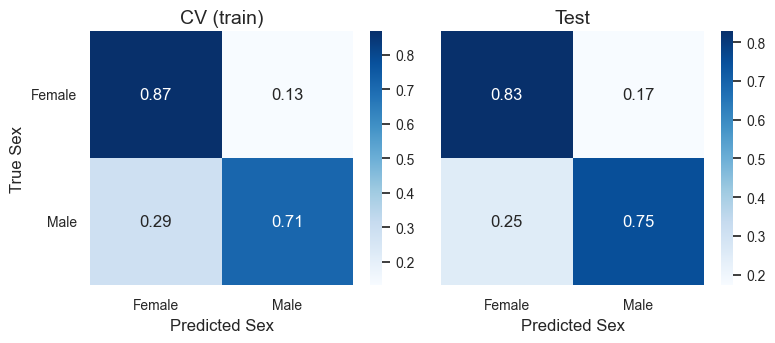

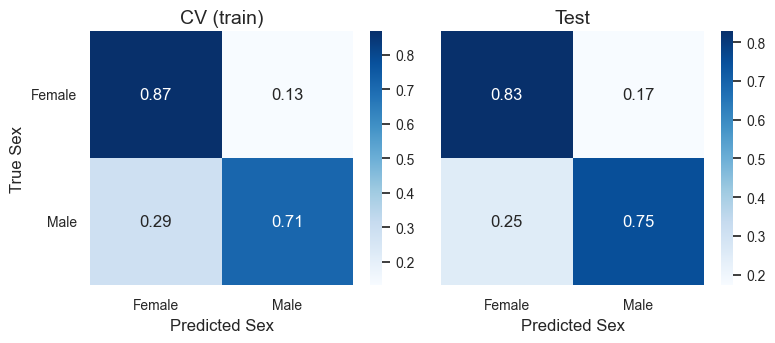

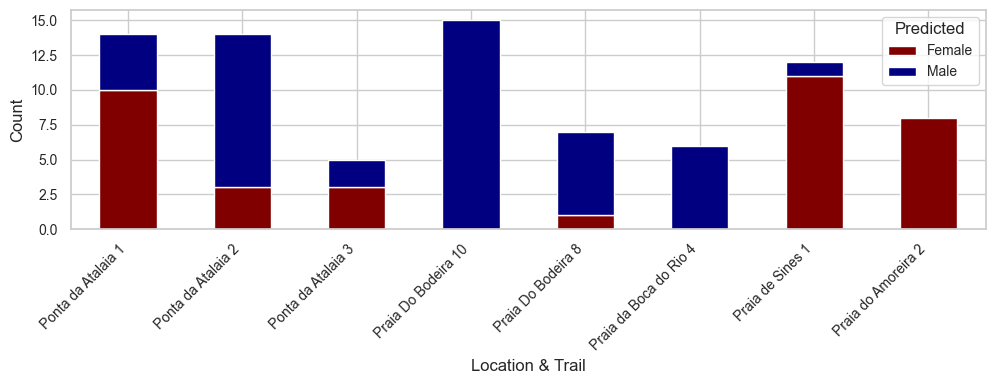

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

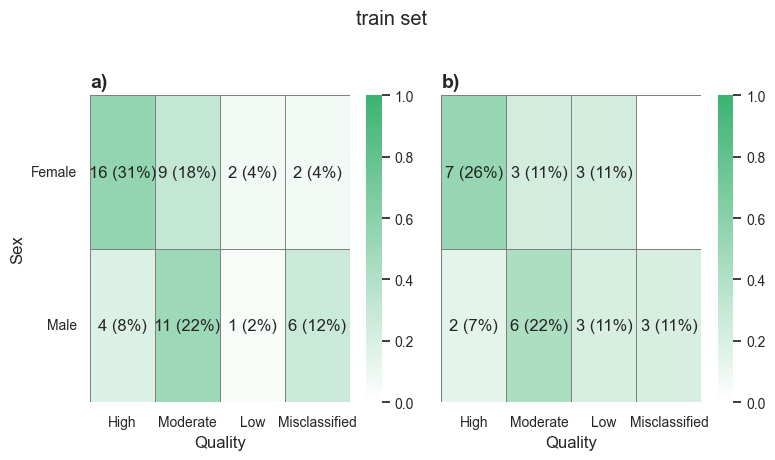

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:573: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warn

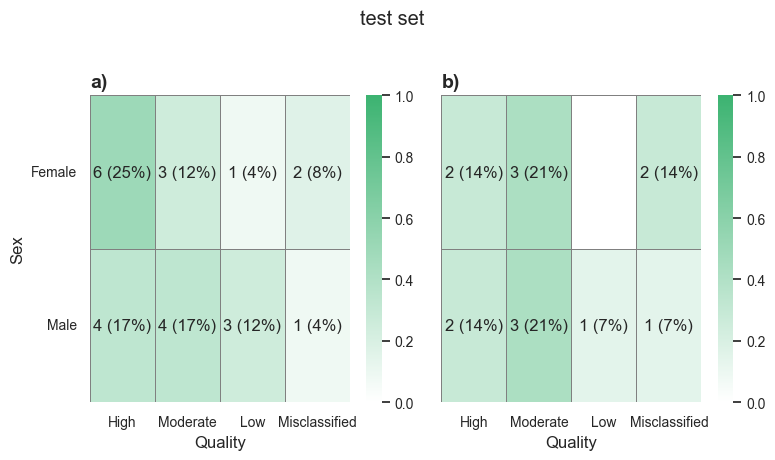

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


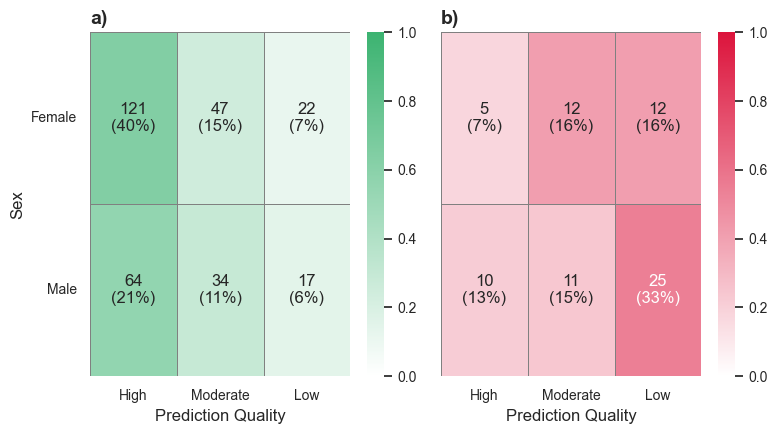

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:744: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(


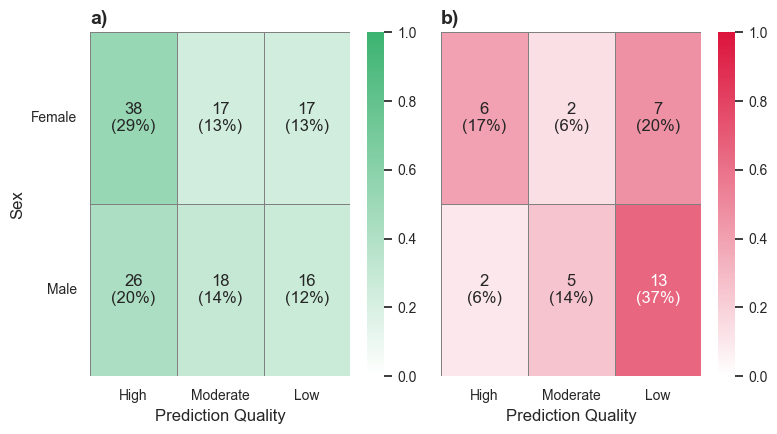

In [ ]:
from FIT_python.pipeline_sex.sex_predict_and_visualisation import (
    plot_confusion_and_inference, 
    plot_quality_grouped, 
    plot_quality_heatmaps, 
    plot_individual_probabilities, 
    plot_confusion
)
from FIT_python import config
import importlib
import pandas as pd
from pathlib import Path

# Config neu laden (falls im gleichen Notebook mehrfach geändert wird)
importlib.reload(config)

# --- Basisverzeichnis aus config ---
base_dir = config.EXPERIMENT_ROOT
sex_dir = base_dir / "Sex_plots"
sex_dir.mkdir(parents=True, exist_ok=True)

print("Experiment root:", base_dir)
print("Sex plot directory:", sex_dir)

# --- Plots erzeugen ---
plot_confusion(df_all)
plot_confusion_and_inference(df_all)
plot_quality_grouped(df_all)   # a) Trail level, b) Individual level
plot_quality_heatmaps(df_all)
# Optional mit Ausgabeordner:
# plot_individual_probabilities(df_all, out_dir=sex_dir)


Baseline Model mit basis FIT parameter

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from FIT_python.pipeline_individual_id.simple_baseline import run_fold_cv, get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Splits aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

# Beispiel: einen Test-Split einer Species laden
test_split = base_dir / "eurasian_otter" / "test.parquet"
if not test_split.exists():
    raise FileNotFoundError(f"Test split not found: {test_split}")

print("Using base_dir:", base_dir)
print("Example test split path:", test_split)

# --- Output-Verzeichnis für Individual ID Ergebnisse ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("Saving results to:", out_base_dir)

results = {}



for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue

    species = sp_dir.name
    print(f"\n##### Starte Pairwise-Analyse für {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    if not train_path.exists() or not test_path.exists():
        print(f"⚠️ Überspringe {species}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)
    feature_cols = get_feature_cols(df_train)

    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1) Cross-Validation mit definierten Folds
    print(f"=== CV für {species} ===")
    if "Fold" not in df_train.columns:
        raise ValueError(f"{species}: Train DataFrame braucht eine 'Fold'-Spalte.")

    cv_out_dir = out_dir / "cv_results"
    cv_out_dir.mkdir(parents=True, exist_ok=True)
    summary_cv = run_fold_cv(
        df_train,
        feature_cols,
        fold_col="Fold",
        out_dir=cv_out_dir,
        reuse_summary=False,
    )
    print(f"✅ CV abgeschlossen für {species}")

    # 2) Test-Paare generieren & Baseline anwenden
    print(f"=== Test-Paare für {species} ===")
    pairs_dir = out_dir / "test_pairs"
    pairs_dir.mkdir(parents=True, exist_ok=True)

    comps_test, _ = generate_pairwise_comparisons_from_df(
        df_test, strategy="select", evaluation=True, subsample=False
    )
    res_df = DistanceBaseline.run(
        train_df=df_train,
        use_sexmodel_prediction=False,
        val_comparisons=comps_test,
        val_df=df_test,
        feature_cols=feature_cols,
        reducers=["lda"],
        selection_method="forward",
        n_components=2,
        n_jobs=-1,
    )
    res_df.to_csv(pairs_dir / f"{species}_pairs.csv", index=False)
    print(f"✅ Test-Paare gespeichert: {pairs_dir / f'{species}_pairs.csv'}")

    # Ergebnisse für später sammeln
    results[species] = {
        "cv_summary": summary_cv,
        "test_pairs": res_df,
    }

print("\n✅ Pairwise-Analyse für alle Spezies abgeschlossen.")


Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\data\splits
Example test split path: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\data\splits\eurasian_otter\test.parquet
Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id

##### Starte Pairwise-Analyse für amur_tiger #####
=== CV für amur_tiger ===


100%|██████████| 91/91 [00:02<00:00, 38.20it/s]?, ?it/s]










Processing Pairs:   0%|          | 0/78 [00:02<?, ?it/s]













Processing Pairs:   0%|          | 0/105 [00:02<?, ?it/s]











Processing Pairs:   0%|          | 0/91 [00:02<?, ?it/s]


✅ CV abgeschlossen für amur_tiger
=== Test-Paare für amur_tiger ===






































100%|██████████| 210/210 [00:05<00:00, 39.23it/s]


✅ Test-Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\amur_tiger\test_pairs\amur_tiger_pairs.csv

##### Starte Pairwise-Analyse für bengal_tiger #####
=== CV für bengal_tiger ===


...

✅ Test-Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\mountain_lion\test_pairs\mountain_lion_pairs.csv

##### Starte Pairwise-Analyse für white_rhino #####
=== CV für white_rhino ===







































































































































































































100%|██████████| 465/465 [00:09<00:00, 49.03it/s]



































































































































Processing Pairs:   0%|          | 0/231 [00:05<?, ?it/s]











































Processing Pairs:   0%|          | 0/91 [00:02<?, ?it/s]































































































































Processing Pairs:   0%|          | 0/231 [00:05<?, ?it/s]



























































































































































































































































100%|██████████| 435/435 [00

✅ CV abgeschlossen für white_rhino
=== Test-Paare für white_rhino ===













































































































































































































































































































































































































































































































































































































































100%|██████████| 780/780 [00:16<00:00, 46.10it/s]


✅ Test-Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\white_rhino\test_pairs\white_rhino_pairs.csv

✅ Pairwise-Analyse für alle Spezies abgeschlossen.


#Basline FIT modelbassiert

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)


# XGBoost Regularization Grid
xgb_param_grid = {
    "model__reg_alpha":  [0.01, 0.1, 1, 10],
    "model__reg_lambda": [0, 0.1, 1, 10]
}

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n=== Distance-Classifier (LDA, k=5) für {species} ===")

    # 1) CV-Paare einlesen
    cv_csv = out_base_dir / species / "cv_results" / "all_folds.csv"
    if not cv_csv.exists():
        print(f"⚠️ CV-Daten fehlen für {species}, überspringe.")
        continue
    df_cv = pd.read_csv(cv_csv)

    # 2) Test-Paare einlesen
    tp_csv = out_base_dir / species / "test_pairs" / f"{species}_pairs.csv"
    if not tp_csv.exists():
        print(f"⚠️ Test-Paare fehlen für {species}, überspringe.")
        continue
    df_tp = pd.read_csv(tp_csv)

    # 3) Distanz-Features auswählen
    dist_cols = [c for c in df_cv.columns if c.startswith(("dist_euclidean","mean_euclidean","median_euclidean","min_","max_"))]
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    # 4) NaN rows droppen
    df_cv = df_cv.dropna(subset=dist_cols)
    df_tp = df_tp.dropna(subset=dist_cols)

    # 5) Daten & PredefinedSplit vorbereiten
    X_cv = df_cv[dist_cols].to_numpy()
    y_cv = df_cv["same_individual"].map({True:1, False:0}).to_numpy()
    ps   = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

    # --- LDA GridSearch ---
    # 6) Pipeline: Scaler → SelectKBest(5) → LDA
    pipe_lda = Pipeline([
        ("scaler",  StandardScaler()),
        ("select",  SelectKBest(mutual_info_classif, k=2)),
        ("model",   LinearDiscriminantAnalysis()),
    ])

    # 7) GridSearchCV über 'shrinkage' und 'solver'
    param_grid_lda = {"model__shrinkage": [None, 0.1, 0.5, 0.9],
                      "model__solver": ["svd","lsqr"]}
    gs_lda = GridSearchCV(
        estimator=pipe_lda,
        param_grid=param_grid_lda,
        scoring="balanced_accuracy",
        cv=ps,
        refit=True,
        n_jobs=-1,
        verbose=1
    )
    gs_lda.fit(X_cv, y_cv)

    # 8) CV-Performance LDA
    y_cv_pred_lda = gs_lda.predict(X_cv)
    acc_cv_lda    = balanced_accuracy_score(y_cv, y_cv_pred_lda)
    cm_cv_lda     = confusion_matrix(y_cv, y_cv_pred_lda, labels=[1,0])
    print(f"→ [LDA] CV balanced_accuracy: {acc_cv_lda:.3f}")
    print(pd.DataFrame(
        cm_cv_lda,
        index=["True=Same","True=Diff"],
        columns=["Pred=Same","Pred=Diff"]
    ))

    # 9) Test-Performance LDA
    X_test = df_tp[dist_cols].to_numpy()
    y_test = df_tp["same_individual"].map({True:1, False:0}).to_numpy()
    y_test_pred_lda = gs_lda.predict(X_test)
    acc_test_lda    = balanced_accuracy_score(y_test, y_test_pred_lda)
    cm_test_lda     = confusion_matrix(y_test, y_test_pred_lda, labels=[1,0])
    print(f"\n→ [LDA] Test balanced_accuracy: {acc_test_lda:.3f}")
    print(pd.DataFrame(
        cm_test_lda,
        index=["True=Same","True=Diff"],
        columns=["Pred=Same","Pred=Diff"]
    ))

    # 10) Top-5 Features LDA
    sel_lda = gs_lda.best_estimator_.named_steps["select"]
    top5_lda = np.array(dist_cols)[sel_lda.get_support()].tolist()
    print(f"→ [LDA] Top-5 Features: {top5_lda}")

    # 11) Ergebnisse speichern LDA
    summary_lda = {
        "species":        species,
        "cv_bal_acc":     acc_cv_lda,
        "test_bal_acc":   acc_test_lda,
        "cv_true_same_pred_same":   int(cm_cv_lda[0,0]),
        "cv_true_same_pred_diff":   int(cm_cv_lda[0,1]),
        "cv_true_diff_pred_same":   int(cm_cv_lda[1,0]),
        "cv_true_diff_pred_diff":   int(cm_cv_lda[1,1]),
        "test_true_same_pred_same": int(cm_test_lda[0,0]),
        "test_true_same_pred_diff": int(cm_test_lda[0,1]),
        "test_true_diff_pred_same": int(cm_test_lda[1,0]),
        "test_true_diff_pred_diff": int(cm_test_lda[1,1]),
        "top5_features":  ";".join(top5_lda)
    }
    out_fp_lda = out_base_dir / species / "distance_lda5_summary.csv"
    pd.DataFrame([summary_lda]).to_csv(out_fp_lda, index=False)
    print(f"Ergebnisse gespeichert in {out_fp_lda}")

    # --- XGBoost GridSearch ---
    print(f"\n=== Distance-Classifier (XGB, k=5) für {species} ===")
    # 6) Pipeline: Scaler → SelectKBest(5) → XGBClassifier
    pipe_xgb = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(mutual_info_classif, k=5)),
        ("model", XGBClassifier(
            use_label_encoder=False,
            eval_metric="logloss",
            booster="gbtree",
            tree_method="hist",
            n_estimators=200
        ))
    ])
    gs_xgb = GridSearchCV(
        estimator=pipe_xgb,
        param_grid=xgb_param_grid,
        scoring="balanced_accuracy",
        cv=ps,
        refit=True,
        n_jobs=-1,
        verbose=1
    )
    gs_xgb.fit(X_cv, y_cv)

    # CV-Performance XGB
    y_cv_pred_xgb = gs_xgb.predict(X_cv)
    acc_cv_xgb    = balanced_accuracy_score(y_cv, y_cv_pred_xgb)
    cm_cv_xgb     = confusion_matrix(y_cv, y_cv_pred_xgb, labels=[1,0])
    print(f"→ [XGB] CV balanced_accuracy: {acc_cv_xgb:.3f}")
    print(pd.DataFrame(
        cm_cv_xgb,
        index=["True=Same","True=Diff"],
        columns=["Pred=Same","Pred=Diff"]
    ))

    # Test-Performance XGB
    y_test_pred_xgb = gs_xgb.predict(X_test)
    acc_test_xgb    = balanced_accuracy_score(y_test, y_test_pred_xgb)
    cm_test_xgb     = confusion_matrix(y_test, y_test_pred_xgb, labels=[1,0])
    print(f"\n→ [XGB] Test balanced_accuracy: {acc_test_xgb:.3f}")
    print(pd.DataFrame(
        cm_test_xgb,
        index=["True=Same","True=Diff"],
        columns=["Pred=Same","Pred=Diff"]
    ))

    # Top-5 Features XGB
    sel_xgb = gs_xgb.best_estimator_.named_steps["select"]
    top5_xgb = np.array(dist_cols)[sel_xgb.get_support()].tolist()
    print(f"→ [XGB] Top-5 Features: {top5_xgb}")

    # Ergebnisse speichern XGB
    summary_xgb = {
        "species":        species,
        "cv_bal_acc":     acc_cv_xgb,
        "test_bal_acc":   acc_test_xgb,
        "cv_true_same_pred_same":   int(cm_cv_xgb[0,0]),
        "cv_true_same_pred_diff":   int(cm_cv_xgb[0,1]),
        "cv_true_diff_pred_same":   int(cm_cv_xgb[1,0]),
        "cv_true_diff_pred_diff":   int(cm_cv_xgb[1,1]),
        "test_true_same_pred_same": int(cm_test_xgb[0,0]),
        "test_true_same_pred_diff": int(cm_test_xgb[0,1]),
        "test_true_diff_pred_same": int(cm_test_xgb[1,0]),
        "test_true_diff_pred_diff": int(cm_test_xgb[1,1]),
        "top5_features":  ";".join(top5_xgb)
    }
    out_fp_xgb = out_base_dir / species / "distance_xgb5_summary.csv"
    pd.DataFrame([summary_xgb]).to_csv(out_fp_xgb, index=False)
    print(f"Ergebnisse gespeichert in {out_fp_xgb}")

# --- Abschließend: Benchmark-Summary über alle Arten (LDA & XGB) ---
bench_lda_recs = []
bench_xgb_recs = []
for summary_csv in sorted(out_base_dir.rglob("distance_lda5_summary.csv")):
    bench_lda_recs.append(pd.read_csv(summary_csv))
for summary_csv in sorted(out_base_dir.rglob("distance_xgb5_summary.csv")):
    bench_xgb_recs.append(pd.read_csv(summary_csv))

benchmark_lda_df = pd.concat(bench_lda_recs, ignore_index=True)
benchmark_xgb_df = pd.concat(bench_xgb_recs, ignore_index=True)
# Merge per species
benchmark_df = pd.merge(
    benchmark_lda_df,
    benchmark_xgb_df,
    on="species",
    suffixes=("_lda","_xgb")
)
# Sort by XGB test accuracy descending
benchmark_df = benchmark_df.sort_values("test_bal_acc_xgb", ascending=False)
# Save combined benchmark
benchmark_csv = out_base_dir / "benchmark_distance_combined.csv"
benchmark_df.to_csv(benchmark_csv, index=False)

print("\n=== Gesamt-Benchmark für Distance-Klassifikatoren ===")
print(benchmark_df)


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\data\splits
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id

=== Distance-Classifier (LDA, k=5) für amur_tiger ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pack

→ [LDA] CV balanced_accuracy: 0.959
           Pred=Same  Pred=Diff
True=Same         38          2
True=Diff         12        366

→ [LDA] Test balanced_accuracy: 0.947
           Pred=Same  Pred=Diff
True=Same         12          1
True=Diff          5        172
→ [LDA] Top-5 Features: ['dist_euclidean', 'mean_euclidean_between']
Ergebnisse gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\amur_tiger\distance_lda5_summary.csv

=== Distance-Classifier (XGB, k=5) für amur_tiger ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [21:10:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


→ [XGB] CV balanced_accuracy: 0.986
           Pred=Same  Pred=Diff
True=Same         39          1
True=Diff          1        377

→ [XGB] Test balanced_accuracy: 0.912
           Pred=Same  Pred=Diff
True=Same         11          2
True=Diff          4        173
→ [XGB] Top-5 Features: ['min_observations', 'max_observations', 'dist_euclidean', 'mean_euclidean_between', 'median_euclidean_between']
Ergebnisse gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\amur_tiger\distance_xgb5_summary.csv

=== Distance-Classifier (LDA, k=5) für bengal_tiger ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


...

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [21:10:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


→ [XGB] CV balanced_accuracy: 1.000
           Pred=Same  Pred=Diff
True=Same         47          0
True=Diff          0        326

→ [XGB] Test balanced_accuracy: 0.984
           Pred=Same  Pred=Diff
True=Same         10          0
True=Diff          3         92
→ [XGB] Top-5 Features: ['max_observations', 'dist_euclidean', 'mean_euclidean_between', 'median_euclidean_between', 'mean_euclidean_within_a']
Ergebnisse gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\mountain_lion\distance_xgb5_summary.csv

=== Distance-Classifier (LDA, k=5) für white_rhino ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits
→ [LDA] CV balanced_accuracy: 0.899
           Pred=Same  Pred=Diff
True=Same        209         32
True=Diff         85       1127

→ [LDA] Test balanced_accuracy: 0.870
           Pred=Same  Pred=Diff
True=Same         77          3
True=Diff        156        544
→ [LDA] Top-5 Features: ['di

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-pack

→ [XGB] CV balanced_accuracy: 0.913
           Pred=Same  Pred=Diff
True=Same        207         34
True=Diff         39       1173

→ [XGB] Test balanced_accuracy: 0.924
           Pred=Same  Pred=Diff
True=Same         76          4
True=Diff         71        629
→ [XGB] Top-5 Features: ['dist_euclidean', 'mean_euclidean_between', 'median_euclidean_between', 'median_euclidean_within_a', 'median_euclidean_within_b']
Ergebnisse gespeichert in c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\white_rhino\distance_xgb5_summary.csv

=== Gesamt-Benchmark für Distance-Klassifikatoren ===
          species  cv_bal_acc_lda  test_bal_acc_lda  \
6   mountain_lion        0.939140          0.978947   
5    lowlandtapir        0.807882          0.972603   
7     white_rhino        0.898544          0.869821   
0      amur_tiger        0.959127          0.947414   
2         cheetah        0.961129          0.935614   
1    bengal_tiger

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [21:10:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


BAseline ERD 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib
from sklearn.preprocessing import MinMaxScaler

from FIT_python.pipeline_individual_id.population_estimation import (
    cluster_population,
    compute_erd,
)

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# --- Distanz-Spalten definieren ---
base_metrics = ["euclidean"]

cutoff_range = np.arange(0.4, 4.2, 0.1)
benchmark_records = []

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    out_dir = out_base_dir / species

    # Lade CV-Paare
    cv_csv = out_dir / "cv_results" / "all_folds.csv"
    if not cv_csv.exists():
        print(f"⚠️ CV-Daten fehlt {species}, überspringe.")
        continue
    df_cv = pd.read_csv(cv_csv)

    # Finde zusätzlich alle Spalten mit "between"
    between_cols = [col for col in df_cv.columns if "between" in col]

    metrics = [f"dist_{m}" for m in base_metrics] + between_cols

    # Lade Test-Paare
    tp_csv = out_dir / "test_pairs" / f"{species}_pairs.csv"
    has_test = tp_csv.exists()
    df_tp    = pd.read_csv(tp_csv) if has_test else None

    # --- Hier holen wir uns pipeline als einzelnes Scalar-Label ---
    pipeline = df_cv["pipeline"].iloc[0]

    for dist_col in metrics:
        if dist_col not in df_cv.columns:
            continue

        for prep in ["raw", "minmax"]:
            benchmark_key = {
                "species":       species,
                "pipeline":      pipeline,
                "dist_col":      dist_col,
                "preprocessing": prep,
            }

            # --- 1) CV-Optimierung ---
            recs = []
            for fold_id, fold_df in df_cv.groupby("fold"):
                trails = sorted({*fold_df["trail_a_id"], *fold_df["trail_b_id"]})
                D = pd.DataFrame(np.nan, index=trails, columns=trails)
                for a, b, d in zip(
                    fold_df["trail_a_id"], fold_df["trail_b_id"], fold_df[dist_col]
                ):
                    D.at[a, b] = D.at[b, a] = d
                np.fill_diagonal(D.values, 0.0)
                D = D.fillna(D.values.max())

                if prep == "minmax":
                    scaler = MinMaxScaler()
                    D[:] = scaler.fit_transform(D)

                true_n = len({*fold_df["ind_a"], *fold_df["ind_b"]})
                for cutoff in cutoff_range:
                    pred_n = cluster_population(D, cutoff)
                    erd    = compute_erd(pred_n, true_n)
                    recs.append({
                        "fold":    fold_id,
                        "cutoff":  cutoff,
                        "erd":     erd,
                        "pred_n":  pred_n,
                        "true_n":  true_n,
                    })

            cut_df = pd.DataFrame(recs)
            mean_erd = cut_df.groupby("cutoff")["erd"].mean().reset_index()
            best     = mean_erd.loc[mean_erd["erd"].idxmin()]
            best_cutoff, mean_erd_cv = float(best["cutoff"]), float(best["erd"])

            # --- 2) Test-ERD berechnen ---
            if has_test:
                trails = sorted({*df_tp["trail_a_id"], *df_tp["trail_b_id"]})
                Dtest = pd.DataFrame(np.nan, index=trails, columns=trails)
                for a, b, d in zip(
                    df_tp["trail_a_id"], df_tp["trail_b_id"], df_tp[dist_col]
                ):
                    Dtest.at[a, b] = Dtest.at[b, a] = d
                np.fill_diagonal(Dtest.values, 0.0)
                Dtest = Dtest.fillna(Dtest.values.max())

                if prep == "minmax":
                    scaler = MinMaxScaler()
                    Dtest[:] = scaler.fit_transform(Dtest)

                true_n_t = len({*df_tp["ind_a"], *df_tp["ind_b"]})
                pred_n_t = cluster_population(Dtest, best_cutoff)
                erd_test = compute_erd(pred_n_t, true_n_t)
            else:
                pred_n_t = np.nan
                true_n_t = np.nan
                erd_test  = np.nan

            benchmark_records.append({
                **benchmark_key,
                "cv_cutoff":    best_cutoff,
                "cv_mean_erd":  mean_erd_cv,
                "cv_mean_pred": cut_df.query(f"cutoff=={best_cutoff}")["pred_n"].mean(),
                "cv_mean_true": cut_df.query(f"cutoff=={best_cutoff}")["true_n"].mean(),
                "test_pred_n":  pred_n_t,
                "test_true_n":  true_n_t,
                "test_erd":     erd_test,
            })

# --- Ausgabe ---
benchmark_df  = pd.DataFrame(benchmark_records)
benchmark_csv = out_base_dir / "benchmark_full_distances.csv"
benchmark_df.to_csv(benchmark_csv, index=False)

print("=== Benchmark Summary ===")
display(benchmark_df)


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\data\splits
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id
=== Benchmark Summary ===


,species,pipeline,dist_col,preprocessing,cv_cutoff,cv_mean_erd,cv_mean_pred,cv_mean_true,test_pred_n,test_true_n,test_erd
0,amur_tiger,forward_no_out_no_scale_k16_lda_nc2_sex_off,dist_euclidean,raw,3.3,0.085714,6.4,7.0,10,9,0.111111
1,amur_tiger,forward_no_out_no_scale_k16_lda_nc2_sex_off,dist_euclidean,minmax,0.6,0.057143,7.0,7.0,10,9,0.111111
2,amur_tiger,forward_no_out_no_scale_k16_lda_nc2_sex_off,mean_euclidean_between,raw,2.8,0.114286,7.8,7.0,11,9,0.222222
3,amur_tiger,forward_no_out_no_scale_k16_lda_nc2_sex_off,mean_euclidean_between,minmax,0.7,0.142857,6.4,7.0,7,9,0.222222
4,amur_tiger,forward_no_out_no_scale_k16_lda_nc2_sex_off,median_euclidean_between,raw,3.6,0.085714,6.4,7.0,9,9,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
203,white_rhino,forward_no_out_no_scale_k16_lda_nc2_sex_off,median_canberra_between,minmax,0.8,0.157143,5.8,6.4,8,9,0.111111
204,white_rhino,forward_no_out_no_scale_k16_lda_nc2_sex_off,mean_braycurtis_between,raw,0.9,0.057143,6.8,6.4,12,9,0.333333
205,white_rhino,forward_no_out_no_scale_k16_lda_nc2_sex_off,mean_braycurtis_between,minmax,0.6,0.028571,6.6,6.4,9,9,0.000000
206,white_rhino,forward_no_out_no_scale_k16_lda_nc2_sex_off,median_braycurtis_between,raw,0.9,0.090476,6.6,6.4,11,9,0.222222


Grid serach mit novelities

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from FIT_python.pipeline_individual_id.simple_baseline import run_fold_cv, get_feature_cols
from FIT_python.pipeline_individual_id.generate_trails_and_trailpairs import generate_pairwise_comparisons_from_df
from FIT_python.pipeline_individual_id.baseline_pipeline import DistanceBaseline
from FIT_python.pipeline_sex.sex_predict_and_visualisation import predict_all
from FIT_python.soft_config import SOFT_CONFIG

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Splits aus config ---
base_dir = cfg.SPLITS_DIR
if not base_dir.exists():
    raise FileNotFoundError(f"Splits directory not found: {base_dir}")

# --- Output-Verzeichnis für Individual ID Ergebnisse ---
out_base_dir = cfg.EXPERIMENT_ROOT / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)


results = {}
k_range = range(2, 21)
selection_methods = [ "lasso", "random_forest","forward",]
sex_flags = [False, True]

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    print(f"\n##### {species} #####")

    train_path = sp_dir / "train.parquet"
    test_path  = sp_dir / "test.parquet"
    if not train_path.exists() or not test_path.exists():
        print(f"⚠️ Überspringe {species}, da train/test fehlt.")
        continue

    df_train = pd.read_parquet(train_path)
    df_test  = pd.read_parquet(test_path)
    feature_cols = get_feature_cols(df_train)

    out_dir = out_base_dir / species
    out_dir.mkdir(parents=True, exist_ok=True)

    # Sammlung aller Paarvergleiche über CV + Test für dieses Species
    master_pairs = []

    # Sex‑Vorhersagen (OOF für Train, voll trainiertes Modell für Test)
    sex_preds = predict_all(species, reuse_csv=True)

    for fs in selection_methods:
        for k in k_range:
            for use_sex in sex_flags:
                tag = f"{fs}_k{k}_{'sex' if use_sex else 'morph'}"
                run_dir = out_dir / tag
                run_dir.mkdir(parents=True, exist_ok=True)

                # --- 1) CV ---
                cv_dir = run_dir / "cv_results"
                cv_dir.mkdir(parents=True, exist_ok=True)
                summary_cv = run_fold_cv(
                    df_train,
                    feature_cols,
                    sex_predictions=sex_preds,
                    fold_col="Fold",
                    out_dir=cv_dir,
                    selection_method=fs,
                    k_features=k,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    reuse_summary=True,
                )
                print(f"CV fertig: {species} – {tag}")

                # CV-Paare laden und annotieren
                cv_pairs_fp = cv_dir / "all_folds.csv"
                if cv_pairs_fp.exists():
                    cv_pairs = pd.read_csv(cv_pairs_fp)
                    cv_pairs["origin"] = "cv"
                    cv_pairs["tag"] = tag
                    master_pairs.append(cv_pairs)

                # --- 2) Test‑Paare ---
                pairs_dir = run_dir / "test_pairs"
                pairs_dir.mkdir(parents=True, exist_ok=True)

                comps_test, _ = generate_pairwise_comparisons_from_df(
                    df_test, strategy="select", evaluation=True, subsample=False
                )

                SOFT_CONFIG["pipeline_individual_id"]["pairwise_defaults"]["k_features"] = k
                res_df = DistanceBaseline.run(
                    train_df=df_train,
                    val_comparisons=comps_test,
                    val_df=df_test,
                    feature_cols=feature_cols,
                    selection_method=fs,
                    reducers=["lda"],
                    n_components=2,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    n_jobs=-1,
                )
                res_df.to_csv(pairs_dir / f"{species}_pairs.csv", index=False)
                print(f"Test‑Paare gespeichert: {pairs_dir / f'{species}_pairs.csv'}")

                # Test-Paare annotieren
                test_pairs = res_df.copy()
                test_pairs["origin"] = "test"
                test_pairs["tag"] = tag
                master_pairs.append(test_pairs)

                results.setdefault(species, []).append({
                    "tag": tag,
                    "cv_summary": summary_cv,
                    "test_pairs": res_df,
                })

    # --- Master-Tabelle für dieses Species ---
    if master_pairs:
        master_df = pd.concat(master_pairs, ignore_index=True)
        master_df.to_csv(out_dir / f"{species}_master_pairs.csv", index=False)

print("\n✅ Analysen für alle Spezies abgeschlossen.")


C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


✅ Using base_dir: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\data\splits
✅ Saving results to: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id

##### amur_tiger #####


Processing Pairs:   0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/66 [00:00<?, ?it/s]

C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


...

Test‑Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\amur_tiger\forward_k14_sex\test_pairs\amur_tiger_pairs.csv
CV fertig: amur_tiger – forward_k15_morph


  0%|          | 0/210 [00:00<?, ?it/s]

C:\Users\Frede\AppData\Local\Temp\ipykernel_30696\3455434841.py:100: UserWarning: Mapped species 'panthera_tigris_altaica' → 'amur_tiger'
  res_df = DistanceBaseline.run(
Processing Pairs:   0%|          | 0/210 [00:06<?, ?it/s]

Test‑Paare gespeichert: c:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_fast\individual_id\amur_tiger\forward_k15_morph\test_pairs\amur_tiger_pairs.csv
CV fertig: amur_tiger – forward_k15_sex


  0%|          | 0/210 [00:00<?, ?it/s]

Benchmark best Individual Classification model for all species 

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import importlib

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

# --- Config laden ---
from FIT_python import config as cfg
importlib.reload(cfg)

# --- Pfade aus Config ---
base_dir = cfg.SPLITS_DIR
out_base_dir = cfg.RESULTS_DIR / "individual_id"
out_base_dir.mkdir(parents=True, exist_ok=True)

print("✅ Using base_dir:", base_dir)
print("✅ Saving results to:", out_base_dir)

# --- Grid für XGBoost ---
xgb_param_grid = {
    "model__reg_alpha":  [0.01, 0.1, 1, 10],
    "model__reg_lambda": [0, 0.1, 1, 10]
}

# --- Iteration über Spezies ---
for sp_dir in sorted(out_base_dir.iterdir()):
    master_fp = sp_dir / f"{sp_dir.name}_master_pairs.csv"
    if not master_fp.exists():
        continue

    df_master = pd.read_csv(master_fp)
    dist_cols = [c for c in df_master.columns
                 if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

    for tag, df_tag in df_master.groupby("tag"):
        print(f"\n=== {sp_dir.name} – {tag} ===")

        # Split in CV / Test
        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=dist_cols)
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=dist_cols)
        if df_cv.empty or df_tp.empty:
            print("⚠️ Daten unvollständig, überspringe.")
            continue

        X_cv = df_cv[dist_cols].to_numpy()
        y_cv = df_cv["same_individual"].map({True: 1, False: 0}).to_numpy()
        ps   = PredefinedSplit(test_fold=df_cv["fold"].to_numpy())

        # --- LDA ---
        pipe_lda = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif, k=5)),
            ("model",  LinearDiscriminantAnalysis())
        ])
        param_grid_lda = {
            "model__shrinkage": [None, 0.1, 0.5, 0.9],
            "model__solver":    ["svd", "lsqr"]
        }
        gs_lda = GridSearchCV(pipe_lda, param_grid_lda,
                              scoring="balanced_accuracy",
                              cv=ps, refit=True, n_jobs=-1, verbose=1)
        gs_lda.fit(X_cv, y_cv)

        X_test = df_tp[dist_cols].to_numpy()
        y_test = df_tp["same_individual"].map({True: 1, False: 0}).to_numpy()

        y_cv_pred   = gs_lda.predict(X_cv)
        y_test_pred = gs_lda.predict(X_test)

        acc_cv   = balanced_accuracy_score(y_cv, y_cv_pred)
        acc_test = balanced_accuracy_score(y_test, y_test_pred)
        cm_cv    = confusion_matrix(y_cv,   y_cv_pred,   labels=[1, 0])
        cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

        sel_lda = gs_lda.best_estimator_.named_steps["select"]
        top5_lda = np.array(dist_cols)[sel_lda.get_support()].tolist()

        out_dir = sp_dir / tag
        out_dir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame([{
            "species": sp_dir.name,
            "tag": tag,
            "cv_bal_acc": acc_cv,
            "test_bal_acc": acc_test,
            "cv_true_same_pred_same":   int(cm_cv[0,0]),
            "cv_true_same_pred_diff":   int(cm_cv[0,1]),
            "cv_true_diff_pred_same":   int(cm_cv[1,0]),
            "cv_true_diff_pred_diff":   int(cm_cv[1,1]),
            "test_true_same_pred_same": int(cm_test[0,0]),
            "test_true_same_pred_diff": int(cm_test[0,1]),
            "test_true_diff_pred_same": int(cm_test[1,0]),
            "test_true_diff_pred_diff": int(cm_test[1,1]),
            "top5_features": ";".join(top5_lda)
        }]).to_csv(out_dir / "distance_lda5_summary.csv", index=False)

        # --- XGBoost ---
        pipe_xgb = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif, k=5)),
            ("model",  XGBClassifier(
                use_label_encoder=False,
                eval_metric="logloss",
                booster="gbtree",
                tree_method="hist",
                n_estimators=200
            ))
        ])
        gs_xgb = GridSearchCV(pipe_xgb, xgb_param_grid,
                              scoring="balanced_accuracy",
                              cv=ps, refit=True, n_jobs=-1, verbose=1)
        gs_xgb.fit(X_cv, y_cv)

        y_cv_pred   = gs_xgb.predict(X_cv)
        y_test_pred = gs_xgb.predict(X_test)

        acc_cv   = balanced_accuracy_score(y_cv, y_cv_pred)
        acc_test = balanced_accuracy_score(y_test, y_test_pred)
        cm_cv    = confusion_matrix(y_cv,   y_cv_pred,   labels=[1, 0])
        cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

        sel_xgb = gs_xgb.best_estimator_.named_steps["select"]
        top5_xgb = np.array(dist_cols)[sel_xgb.get_support()].tolist()

        pd.DataFrame([{
            "species": sp_dir.name,
            "tag": tag,
            "cv_bal_acc": acc_cv,
            "test_bal_acc": acc_test,
            "cv_true_same_pred_same":   int(cm_cv[0,0]),
            "cv_true_same_pred_diff":   int(cm_cv[0,1]),
            "cv_true_diff_pred_same":   int(cm_cv[1,0]),
            "cv_true_diff_pred_diff":   int(cm_cv[1,1]),
            "test_true_same_pred_same": int(cm_test[0,0]),
            "test_true_same_pred_diff": int(cm_test[0,1]),
            "test_true_diff_pred_same": int(cm_test[1,0]),
            "test_true_diff_pred_diff": int(cm_test[1,1]),
            "top5_features": ";".join(top5_xgb)
        }]).to_csv(out_dir / "distance_xgb5_summary.csv", index=False)

# --- Benchmark zusammenfassen ---
bench_lda, bench_xgb = [], []
for summary_csv in out_base_dir.rglob("distance_lda5_summary.csv"):
    bench_lda.append(pd.read_csv(summary_csv))
for summary_csv in out_base_dir.rglob("distance_xgb5_summary.csv"):
    bench_xgb.append(pd.read_csv(summary_csv))

benchmark_df = pd.merge(
    pd.concat(bench_lda, ignore_index=True),
    pd.concat(bench_xgb, ignore_index=True),
    on=["species", "tag"],
    suffixes=("_lda", "_xgb")
).sort_values(["species", "tag"])

benchmark_df.to_csv(out_base_dir / "benchmark_distance_combined.csv", index=False)
print("\n=== Gesamt-Benchmark ===")
print(benchmark_df)


Benchmark improvements erd pipliens

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

from FIT_python.pipeline_individual_id.population_estimation import (
    cluster_population,
    compute_erd,
)

# ------------------------------------------------------------------
# Pfade & Einstellungen
# ------------------------------------------------------------------
out_base_dir = Path("experiments/dissertation_notebook/results/individual_id")
base_metrics  = ["euclidean","manhattan","cosine","chebyshev","canberra","braycurtis"]
cutoff_range  = np.arange(0.4, 4.2, 0.1)

benchmark_records = []

# ------------------------------------------------------------------
# Für jede Spezies die Master‑Pairs einlesen und pro Pipeline auswerten
# ------------------------------------------------------------------
for sp_dir in sorted(out_base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species   = sp_dir.name
    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        print(f"⚠️ {species}: Master-Datei fehlt, überspringe.")
        continue

    df_master = pd.read_csv(master_fp)

    # Distanzspalten (alle standardisierten + „between“‑Features)
    between_cols = [c for c in df_master.columns if "between" in c]
    metrics = [f"dist_{m}" for m in base_metrics] + between_cols

    # --------------------------------------------------------------
    # pro Pipeline-Tag getrennte Analyse
    # --------------------------------------------------------------
    for tag, df_tag in df_master.groupby("tag"):
        df_cv   = df_tag[df_tag["origin"] == "cv"]
        df_test = df_tag[df_tag["origin"] == "test"]

        for dist_col in metrics:
            if dist_col not in df_tag.columns:
                continue

            for prep in ["raw", "minmax"]:
                bench_key = {
                    "species":       species,
                    "tag":           tag,
                    "dist_col":      dist_col,
                    "preprocessing": prep,
                }

                # ---------------- CV: Cutoff-Optimierung ----------------
                recs = []
                for fold_id, fold_df in df_cv.groupby("fold"):
                    trails = sorted({*fold_df["trail_a_id"], *fold_df["trail_b_id"]})
                    D = pd.DataFrame(np.nan, index=trails, columns=trails)
                    for a, b, d in zip(
                        fold_df["trail_a_id"], fold_df["trail_b_id"], fold_df[dist_col]
                    ):
                        D.at[a, b] = D.at[b, a] = d
                    np.fill_diagonal(D.values, 0.0)
                    D = D.fillna(D.values.max())

                    if prep == "minmax":
                        D[:] = MinMaxScaler().fit_transform(D)

                    true_n = len({*fold_df["ind_a"], *fold_df["ind_b"]})
                    for cutoff in cutoff_range:
                        pred_n = cluster_population(D, cutoff)
                        erd    = compute_erd(pred_n, true_n)
                        recs.append({
                            "fold":   fold_id,
                            "cutoff": cutoff,
                            "erd":    erd,
                            "pred_n": pred_n,
                            "true_n": true_n,
                        })

                cut_df   = pd.DataFrame(recs)
                mean_erd = cut_df.groupby("cutoff")["erd"].mean().reset_index()
                best     = mean_erd.loc[mean_erd["erd"].idxmin()]
                best_cutoff = float(best["cutoff"])
                mean_erd_cv = float(best["erd"])

                # ---------------- Test-ERD (falls vorhanden) ------------
                if not df_test.empty:
                    trails = sorted({*df_test["trail_a_id"], *df_test["trail_b_id"]})
                    Dtest = pd.DataFrame(np.nan, index=trails, columns=trails)
                    for a, b, d in zip(
                        df_test["trail_a_id"], df_test["trail_b_id"], df_test[dist_col]
                    ):
                        Dtest.at[a, b] = Dtest.at[b, a] = d
                    np.fill_diagonal(Dtest.values, 0.0)
                    Dtest = Dtest.fillna(Dtest.values.max())

                    if prep == "minmax":
                        Dtest[:] = MinMaxScaler().fit_transform(Dtest)

                    true_n_t = len({*df_test["ind_a"], *df_test["ind_b"]})
                    pred_n_t = cluster_population(Dtest, best_cutoff)
                    erd_test = compute_erd(pred_n_t, true_n_t)
                else:
                    pred_n_t = true_n_t = erd_test = np.nan

                benchmark_records.append({
                    **bench_key,
                    "cv_cutoff":    best_cutoff,
                    "cv_mean_erd":  mean_erd_cv,
                    "cv_mean_pred": cut_df.query(f"cutoff=={best_cutoff}")["pred_n"].mean(),
                    "cv_mean_true": cut_df.query(f"cutoff=={best_cutoff}")["true_n"].mean(),
                    "test_pred_n":  pred_n_t,
                    "test_true_n":  true_n_t,
                    "test_erd":     erd_test,
                })

# ------------------------------------------------------------------
# Benchmark-Tabelle speichern
# ------------------------------------------------------------------
benchmark_df = pd.DataFrame(benchmark_records)
benchmark_df.to_csv(out_base_dir / "benchmark_full_distances.csv", index=False)

print("=== Benchmark Summary ===")
display(benchmark_df)


#Evaludation of different approaches to get best classification model

#tabele that comparse the basline model to the best piplines per species to base model. MEan rank for ERD und Balaced accuracy for CV and Testset = definition of best model

Sequential holdout for 3 best piplines for species eurasian otter.  One seqneutial holdout for Train set [2,4,6,8,10,12,14,16] individuals 10 iterations goal get best cutoff same method as in notebook block above;  One sequence [2,4,6,8] evaluate best cutoof on tesste sequential holdouts. Visuslisie predicted vs True numbers of individual in set and regresion line for best cutoff for train and test set